# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.5 MB/s eta 0:00:00


In [29]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from pytorch_tabnet.tab_model import TabNetClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# 전처리

# 데이터 불러오기
file_path = 'train2.csv'
data = pd.read_csv(file_path)

# ID, Customer_ID, Name, SSN: 예측에 무의미한 식별자는 제거
data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

# Type_of_Loan: 대출 건수(loan_count)로 수치화해 정보 보존
# 쉼표로 구분되어 있기 때문에 쉼표를 기준으로 스플릿 후 수치화함
data['loan_count'] = data['Type_of_Loan'].apply(
    lambda x: 0 if x in ['No Data', 'not specified'] else len(str(x).split(','))
)
data = data.drop(columns=['Type_of_Loan'])

# 파생변수 생성
# debt_to_income(부채/소득)
# delayed_interest(연체횟수×이자율)
# 아래의 EDA에서 Outstanding_Deb, Interest_Rat, Num_of_Delayed_Payment가
# Credit_Score와 가장 강한 연관을 보여, 이를 조합한 변수가 유효하다고 판단
data['debt_to_income']   = data['Outstanding_Debt'] / (data['Annual_Income'] + 1)
data['delayed_interest'] = data['Num_of_Delayed_Payment'] * data['Interest_Rate']

# 관련이 낮은 Feature 제거 (Month, Num_Bank_Accounts, Num_Credit_Card)
data = data.drop(columns=['Month', 'Num_Bank_Accounts', 'Num_Credit_Card'])

# 범주형 변수 원핫 인코딩 (One-Hot Encoding) --> TabNet 성능 극대화
CAT_COLS = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
data = pd.get_dummies(data, columns=CAT_COLS, dtype=float)

# 타겟 인코딩 (Credit_Score)
le_encoder = LabelEncoder()
data['Credit_Score'] = le_encoder.fit_transform(data['Credit_Score'])


/tmp/ipykernel_6127/3815194715.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0,1].boxplot(data_box, labels=order, patch_artist=True)


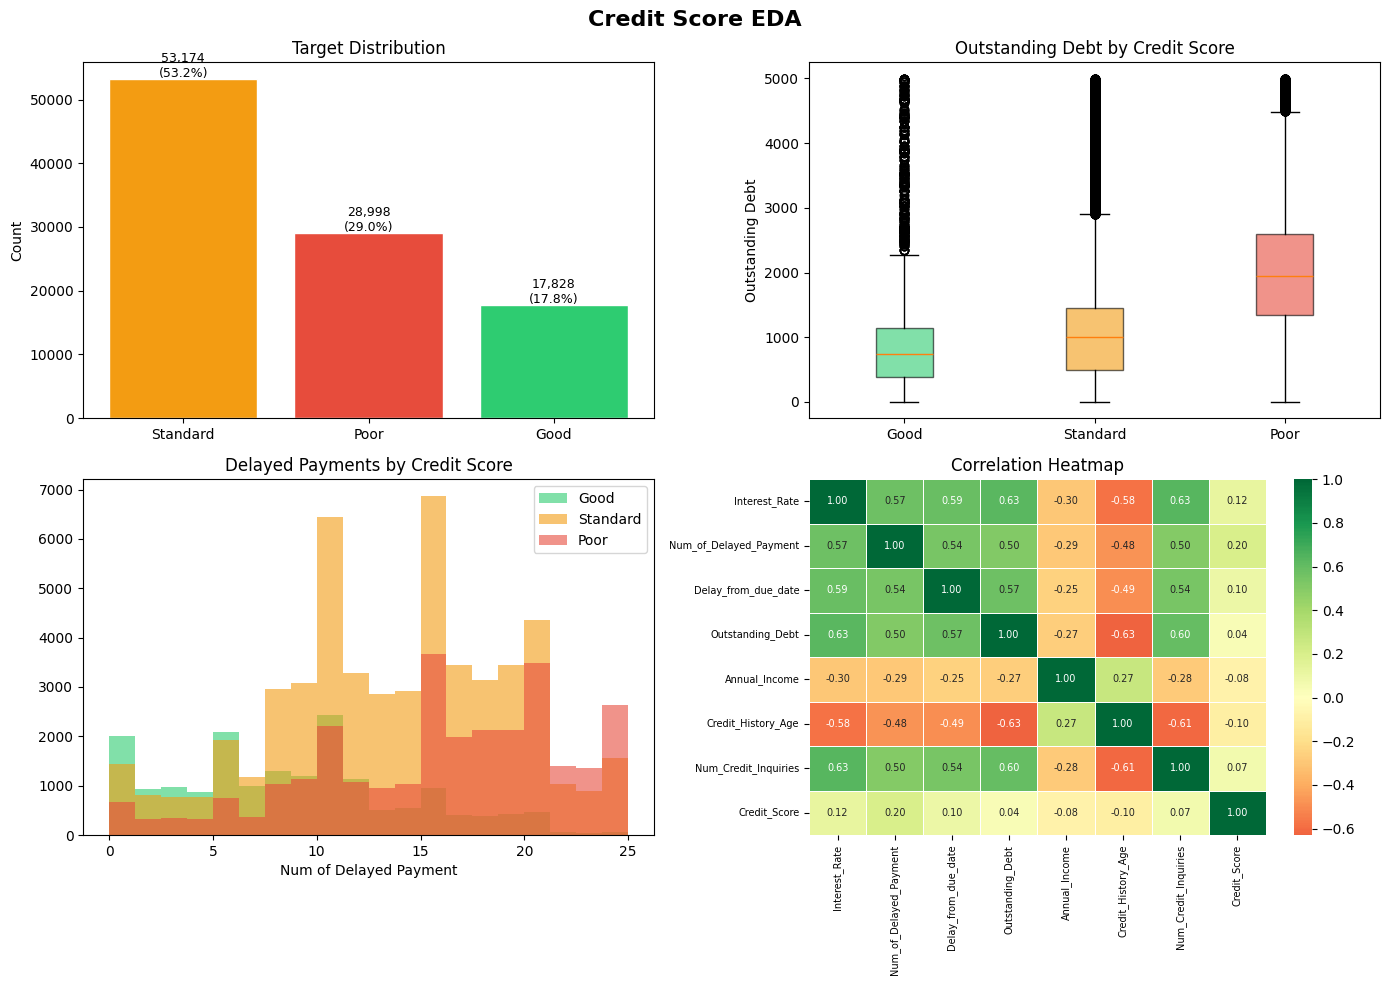

In [31]:
# EDA 진행
order  = ['Good', 'Standard', 'Poor']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Score EDA', fontsize=16, fontweight='bold')

data['_label'] = le_encoder.inverse_transform(data['Credit_Score'])

# 1. Target Distribution
# 전체 데이터셋에서 신용 등급별 비중을 살펴본 결과, 클래스 불균형이 존재함을 확인함
# Standard 등급이 53.2%로 절반 이상을 차지하고, Good 등급은 17.8%로 가장 적은 비중을 차지함
counts      = data['Credit_Score'].value_counts()
label_names = le_encoder.inverse_transform(counts.index)
bar_colors  = [colors[order.index(n)] for n in label_names]
axes[0,0].bar(label_names, counts.values, color=bar_colors, edgecolor='white')
axes[0,0].set_title('Target Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v+300, f'{v:,}\n({v/len(data)*100:.1f}%)', ha='center', fontsize=9)

# 2. Outstanding Debt by Credit Score
# 신용 등급이 낮아질수록 미결제 부채액의 범위가 뚜렷하게 상승함
# 부채 규모가 신용 등급을 결정하는 강력한 변별력을 가진 지표임을 확인.
data_box = [data[data['_label']==cs]['Outstanding_Debt'].values for cs in order]
bp = axes[0,1].boxplot(data_box, labels=order, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[0,1].set_title('Outstanding Debt by Credit Score')
axes[0,1].set_ylabel('Outstanding Debt')

# 3. Delayed Payments by Credit Score
# 연체 횟수가 많을수록 Poor로 가는 경향이 뚜렷하고,
# 연체 횟수가 증가함에 따라 신용 등급이 하락하는 양상을 보임.
# 특정 횟수 이상 연체 시 Good 등급에서 사실상 배제되므로, 연체 횟수는 등급 상한을 결정하는 주요 변수임.
for cs, c in zip(order, colors):
    axes[1,0].hist(data[data['_label']==cs]['Num_of_Delayed_Payment'], bins=20, alpha=0.6, label=cs, color=c)
axes[1,0].set_title('Delayed Payments by Credit Score')
axes[1,0].set_xlabel('Num of Delayed Payment')
axes[1,0].legend()

# 4. Correlation Heatmap
# Interest_Rate, Outstanding_Debt, Num_of_Delayed_Payment 간 강한 양의 상관관계 확인 (리스크 그룹 동기화).
# 타겟(Credit_Score)과 단일 변수 간의 직접 상관계수는 낮아, 단순 선형관계보다 다중 변수의 비선형적 조합이 중요.
# 이러한 데이터 특성은 변수 조합을 스스로 학습하는 TabNet의 도입 근거가 됨.
key_cols = ['Interest_Rate', 'Num_of_Delayed_Payment', 'Delay_from_due_date',
            'Outstanding_Debt', 'Annual_Income', 'Credit_History_Age',
            'Num_Credit_Inquiries', 'Credit_Score']
corr = data[key_cols].corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 7})
axes[1,1].set_title('Correlation Heatmap')
axes[1,1].tick_params(labelsize=7)

plt.tight_layout()
plt.show()
data = data.drop(columns=['_label'])

In [32]:
# X, y값 지정
X = data.drop(columns=['Credit_Score']).values
y = data['Credit_Score'].values

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 수치형 변수 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Feature Selection과 모델 선택, 튜닝 기준
# 1. Feature Selection: EDA 결과 타겟(Credit_Score)과 가장 강한 연관성을 보인 Outstanding_Debt,
#    Interest_Rate, Num_of_Delayed_Payment를 핵심 변수로 선정하고, 이를 조합한 파생변수를 생성해 유효성을 높임.
#    타겟과 상관관계가 미미한 Month, Num_Bank_Accounts 등은 모델 노이즈 방지를 위해 선제적으로 제거함.
# 2. 모델 선택: 정형 데이터 내 복잡한 비선형 패턴과 변수 간 상호작용을 스스로 학습하는 TabNet 사용.
# 3. 튜닝 기준: 과적합 방지와 연산 속도 확보를 위해 모델을 경량화(n_d=32, n_a=32, n_steps=3)함.
#    옵티마이저는 정형 데이터에 안정적인 AdamW(weight_decay=1e-5)를 적용했고,
#    batch_size=512로 속도와 성능의 밸런스를 맞췄으며 클래스 불균형은 weights=1로 해결함.

device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 정의
clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=3,
    gamma=1.3, n_independent=2, n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_params={"T_max": 50},
    mask_type='entmax',
    device_name=device
)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=50,
    patience=15,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    weights=1,
    drop_last=False
)

# validation score 출력
# 검증 데이터에 대한 전체 예측 성능을 파악하기 위해 accuracy_score 출력
# 타겟 데이터의 클래스 불균형(Standard 편향)을 고려하여 classification_report를 함께 출력
preds = clf.predict(X_test)

print(f'\nTabNet Validation Accuracy: {accuracy_score(y_test, preds):.4f}')
print("\n[Classification Report]")
print(classification_report(y_test, preds, target_names=le_encoder.classes_))


# 개선사항
# 1. 정형 데이터 처리에 특화된 TabNet으로 교체하여 비선형 패턴 및 변수 조합 학습력 극대화
# 2. 범주형 인코딩 최적화: Label Encoding이 유발하는 수치적 서열 오해를 One-Hot Encoding으로 해결하여 모델 피처 이해도 대폭 향상
# 3. 클래스 불균형 보완: 손실 함수 가중치(weights=1) 자동 적용으로, 상대적으로 비중이 적은 Good/Poor 클래스에 대한 예측 재현율(Recall) 향상
# 4. 도메인 기반 파생 변수 도입: EDA 통찰을 바탕으로 실제 대출 심사 지표와 유사한 부채/소득 비율(debt_to_income) 등을 추가하여 분류 변별력 강화
# 5. 모델 규제 및 학습 효율화: AdamW의 가중치 감쇠, 조기 종료(patience=15), 적정 배치 사이즈(512)를 조합하여 과적합을 방지하고 안정적인 수렴 달성

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.79631 | train_accuracy: 0.67738 | valid_accuracy: 0.67445 |  0:00:07s
epoch 1  | loss: 0.71078 | train_accuracy: 0.67529 | valid_accuracy: 0.67135 |  0:00:14s
epoch 2  | loss: 0.70132 | train_accuracy: 0.67886 | valid_accuracy: 0.67445 |  0:00:22s
epoch 3  | loss: 0.6896  | train_accuracy: 0.67874 | valid_accuracy: 0.67555 |  0:00:29s
epoch 4  | loss: 0.68808 | train_accuracy: 0.67382 | valid_accuracy: 0.6699  |  0:00:36s
epoch 5  | loss: 0.68423 | train_accuracy: 0.6764  | valid_accuracy: 0.6733  |  0:00:43s
epoch 6  | loss: 0.67515 | train_accuracy: 0.69179 | valid_accuracy: 0.68745 |  0:00:51s
epoch 7  | loss: 0.66546 | train_accuracy: 0.68571 | valid_accuracy: 0.68065 |  0:00:58s
epoch 8  | loss: 0.66139 | train_accuracy: 0.67916 | valid_accuracy: 0.67095 |  0:01:05s
epoch 9  | loss: 0.65476 | train_accuracy: 0.691   | valid_accuracy: 0.68245 |  0:01:13s
epoch 10 | loss: 0.64707 | train_accuracy: 0.68971 | valid_accuracy: 0.6824  |  0:01:20s
epoch 11 | loss: 0.63

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



TabNet Validation Accuracy: 0.7776

[Classification Report]
              precision    recall  f1-score   support

        Good       0.66      0.89      0.76      3566
        Poor       0.73      0.90      0.80      5799
    Standard       0.89      0.67      0.77     10635

    accuracy                           0.78     20000
   macro avg       0.76      0.82      0.78     20000
weighted avg       0.80      0.78      0.78     20000

